   student_id  age gender academic_level  study_hours  self_study_hours  \
0           1   18  Other    High School         7.64              1.56   
1           2   18  Other    High School         2.21              2.22   
2           3   22   Male    High School         3.45              0.00   
3           4   17  Other    High School         5.75              2.08   
4           5   19  Other    High School         6.83              1.72   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  2.20                3.05          2.19         6.52  ...   
1                  2.10                1.65          2.55         5.97  ...   
2                  0.29                1.34          2.08         8.39  ...   
3                  3.01                2.27          2.20         6.31  ...   
4                  3.33                2.65          0.70         8.01  ...   

   exercise_minutes  caffeine_intake_mg  part_time_job  upcoming_deadline 

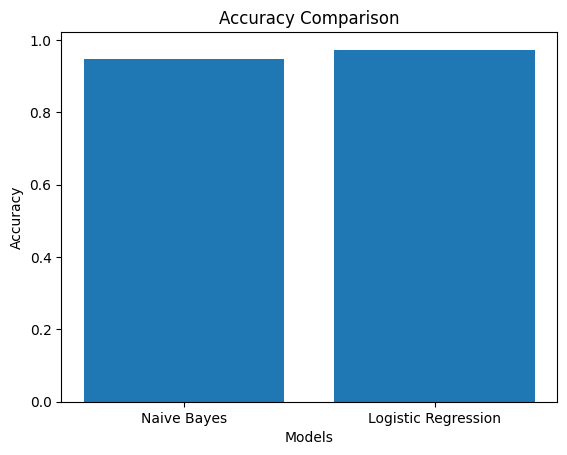

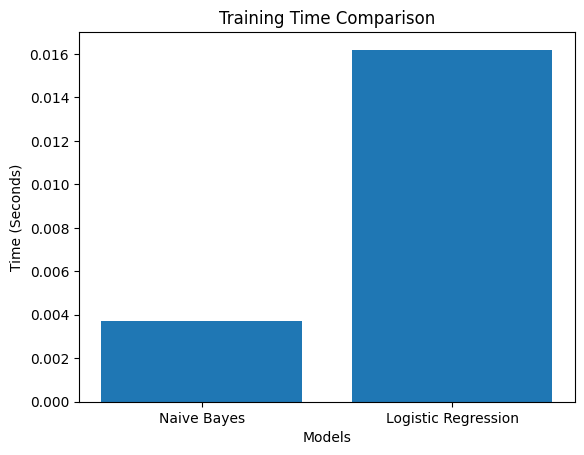

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("ultimate_student_productivity_ds.csv")

print(df.head())

df.info()

df["Target"] = (df["exam_score"] >= 40).astype(int)

print(df["Target"].value_counts())

x = df.drop(["student_id", "exam_score", "Target"], axis=1)

y = df["Target"]

x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

nb = GaussianNB()

start_nb = time.time()

nb.fit(x_train, y_train)

nb_time = time.time() - start_nb

nb_pred = nb.predict(x_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("----- Naive Bayes -----")

print("Accuracy :", nb_accuracy)

print("Training Time :", nb_time)

print("Confusion Matrix :\n",
      confusion_matrix(y_test, nb_pred))

print("Classification Report :\n",
      classification_report(y_test, nb_pred))

lr = LogisticRegression(max_iter=1000)

start_lr = time.time()

lr.fit(x_train, y_train)

lr_time = time.time() - start_lr

lr_pred = lr.predict(x_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("----- Logistic Regression -----")

print("Accuracy :", lr_accuracy)

print("Training Time :", lr_time)

print("Confusion Matrix :\n",
      confusion_matrix(y_test, lr_pred))

print("Classification Report :\n",
      classification_report(y_test, lr_pred))

models = ["Naive Bayes", "Logistic Regression"]

accuracies = [nb_accuracy, lr_accuracy]

plt.figure()

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

times = [nb_time, lr_time]

plt.figure()

plt.bar(models, times)

plt.title("Training Time Comparison")

plt.xlabel("Models")

plt.ylabel("Time (Seconds)")

plt.show()